#  Investigation for Cyanobacteria in lac Saint-Ferreol (2026 Summer)

In [1]:
import os
import tempfile
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import GRSl2bgen
import xarray as xr

opj = os.path.join
print(f'GRSl2bgen: {GRSl2bgen.__version__}')

GRSl2bgen: 0.0.2


## Load Saint-Ferreol .zarr scene

In [2]:
# l2a_path = "/home/somukh/DestinE/desp-products/DESP_wat_qual/L2A/GRS_PC_v02_01_09/T31TDJ/2026/07/08/S2C_L2A_GRS_20260708T104621_N0512_T31TDJ_20260713T144401_v02_01_09.zarr"
# l2a_path = "/home/somukh/DestinE/desp-products/DESP_wat_qual/L2A/GRS_PC_v02_01_09/T31TDJ/2026/07/15/S2C_L2A_GRS_20260715T103621_N0512_T31TDJ_20260722T072138_v02_01_09.zarr"
# l2a_path = "/home/somukh/DestinE/desp-products/DESP_wat_qual/L2A/GRS_PC_v02_01_09/T31TDJ/2026/07/18/S2C_L2A_GRS_20260718T104621_N0512_T31TDJ_20260722T082108_v02_01_09.zarr"
# l2a_path = "/home/somukh/DestinE/desp-products/DESP_wat_qual/L2A/GRS_PC_v02_01_09/T31TDJ/2026/07/20/S2A_L2A_GRS_20260720T105051_N0512_T31TDJ_20260727T194122_v02_01_09.zarr" 
# l2a_path = "/home/somukh/DestinE/desp-products/DESP_wat_qual/L2A/GRS_PC_v02_01_09/T31TDJ/2026/07/28/S2C_L2A_GRS_20260728T104621_N0512_T31TDJ_20260803T222614_v02_01_09.zarr"
l2a_path = "/home/somukh/DestinE/desp-products/DESP_wat_qual/L2A/GRS_PC_v02_01_09/T31TDJ/2026/08/02/S2B_L2A_GRS_20260802T104619_N0512_T31TDJ_20260803T184147_v02_01_09.zarr"

prod = GRSl2bgen.Product(l2a_path)
prod.raster

INFO:root:Load L2A from files


<xarray.Dataset> Size: 4GB
Dimensions:             (y: 5490, x: 5490, wl: 11)
Coordinates:
  * y                   (y) float64 44kB 4.9e+06 4.9e+06 ... 4.79e+06 4.79e+06
  * x                   (x) float64 44kB 4e+05 4e+05 ... 5.097e+05 5.098e+05
  * wl                  (wl) int64 88B 443 490 560 665 705 ... 842 865 1610 2190
    central_wavelength  (wl) float32 44B dask.array<chunksize=(11,), meta=np.ndarray>
    band                int64 8B ...
    spatial_ref         int64 8B ...
    time                datetime64[ns] 8B ...
Data variables:
    aot550              (y, x) float64 241MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    BRDFg               (y, x) float64 241MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    dem                 (y, x) float64 241MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    flags               (y, x) float64 241MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    mask                (y, x) float32 121MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    raa                 (y, x) float64 241MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    Rrs                 (wl, y, x) float64 3GB dask.array<chunksize=(11, 1024, 1024), meta=np.ndarray>
    sza                 (y, x) float64 241MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    vza                 (y, x) float64 241MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
Attributes: (12/73)
    CLOUD_COVERAGE_ASSESSMENT:           6.447599827471
    DATATAKE_1_DATATAKE_SENSING_START:   2026-08-02T10:46:19.024Z
    DATATAKE_1_DATATAKE_TYPE:            INS-NOBS
    DATATAKE_1_ID:                       GS2B_20260802T104619_049126_N05.12
    DATATAKE_1_SENSING_ORBIT_DIRECTION:  DESCENDING
    DATATAKE_1_SENSING_ORBIT_NUMBER:     51
    ...                                  ...
    sunglint_threshold:                  0.2
    tile:                                31TDJ
    version:                             2.1.7
    vis_swir_index_threshold:            0.0
    water_vapor_transmittance_file:      /app/.venv/lib/python3.12/site-packa...
    wl_to_process:                       [443, 490, 560, 665, 705, 740, 783, ...

## Run full pipeline and save L2B .nc

In [3]:
out_dir = '/home/somukh/dev_code/fr_2030_SaintFerreol_test/'
os.makedirs(out_dir, exist_ok=True)

# Build output name from the input scene name to avoid overwriting files
l2a_name = os.path.basename(l2a_path)
l2b_name = l2a_name
l2b_name = l2b_name.replace('_L2A_', '_L2B_').replace('MSIL2A', 'MSIL2B')
if l2b_name.endswith('.zarr'):
    l2b_name = l2b_name[:-5] + '.nc'
elif l2b_name.endswith('.nc'):
    pass
else:
    l2b_name = l2b_name + '.nc'

l2b_path = opj(out_dir, l2b_name)
process = GRSl2bgen.Process(l2a_path, l2b_path)
process.execute()
process.write_output()
print('Saved:', l2b_path)
process.l2b.l2b_prod

INFO:root:import l2a product
INFO:root:Load L2A from files
INFO:root:get OWT classification
INFO:root:OWT classification
INFO:root:success
INFO:root:construct xarray owt product
INFO:root:OWT classification
INFO:root:success
INFO:root:construct xarray owt product
INFO:root:OWT classification
INFO:root:success
INFO:root:construct xarray owt product
INFO:root:get SPM parameters
/home/somukh/dev_code/GRSl2bgen/GRSl2bgen/suspended_particulate_matter.py:54: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  self.output = xr.merge([self.spm_obs2co, self.turbi_dogliotti, self.spm_nechad]).drop_vars('wl')
/home/somukh/dev_code/GRSl2bgen/.venv/lib/python3.12/site-packages/d

Saved: /home/somukh/dev_code/fr_2030_SaintFerreol_test/S2B_L2B_GRS_20260802T104619_N0512_T31TDJ_20260803T184147_v02_01_09.nc


<xarray.Dataset> Size: 3GB
Dimensions:                 (y: 5490, x: 5490)
Coordinates:
  * y                       (y) float64 44kB 4.9e+06 4.9e+06 ... 4.79e+06
  * x                       (x) float64 44kB 4e+05 4e+05 ... 5.097e+05 5.098e+05
    band                    int64 8B 1
    spatial_ref             int64 8B 0
    time                    datetime64[ns] 8B 2026-08-02T10:46:19
    central_wavelength      float32 4B 739.1
Data variables: (12/17)
    owt_dist_Spyrakos2018   (y, x) float32 121MB nan nan nan nan ... nan nan nan
    owt_index_Spyrakos2018  (y, x) float32 121MB nan nan nan nan ... nan nan nan
    owt_dist_Bi2024         (y, x) float32 121MB nan nan nan nan ... nan nan nan
    owt_index_Bi2024        (y, x) float32 121MB nan nan nan nan ... nan nan nan
    owt_dist_Ta2025         (y, x) float32 121MB nan nan nan nan ... nan nan nan
    owt_index_Ta2025        (y, x) float32 121MB nan nan nan nan ... nan nan nan
    ...                      ...
    TURB_dogliotti          (y, x) float64 241MB nan nan nan nan ... nan nan nan
    SPM_nechad              (y, x) float64 241MB nan nan nan nan ... nan nan nan
    acdom_B15               (y, x) float64 241MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    Kd_par                  (y, x) float64 241MB nan nan nan nan ... nan nan nan
    flags                   (y, x) float64 241MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    mask                    (y, x) float32 121MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
Attributes: (12/73)
    CLOUD_COVERAGE_ASSESSMENT:           6.447599827471
    DATATAKE_1_DATATAKE_SENSING_START:   2026-08-02T10:46:19.024Z
    DATATAKE_1_DATATAKE_TYPE:            INS-NOBS
    DATATAKE_1_ID:                       GS2B_20260802T104619_049126_N05.12
    DATATAKE_1_SENSING_ORBIT_DIRECTION:  DESCENDING
    DATATAKE_1_SENSING_ORBIT_NUMBER:     51
    ...                                  ...
    sunglint_threshold:                  0.2
    tile:                                31TDJ
    version:                             2.1.7
    vis_swir_index_threshold:            0.0
    water_vapor_transmittance_file:      /app/.venv/lib/python3.12/site-packa...
    wl_to_process:                       [443, 490, 560, 665, 705, 740, 783, ...

## Plot Chl outputs

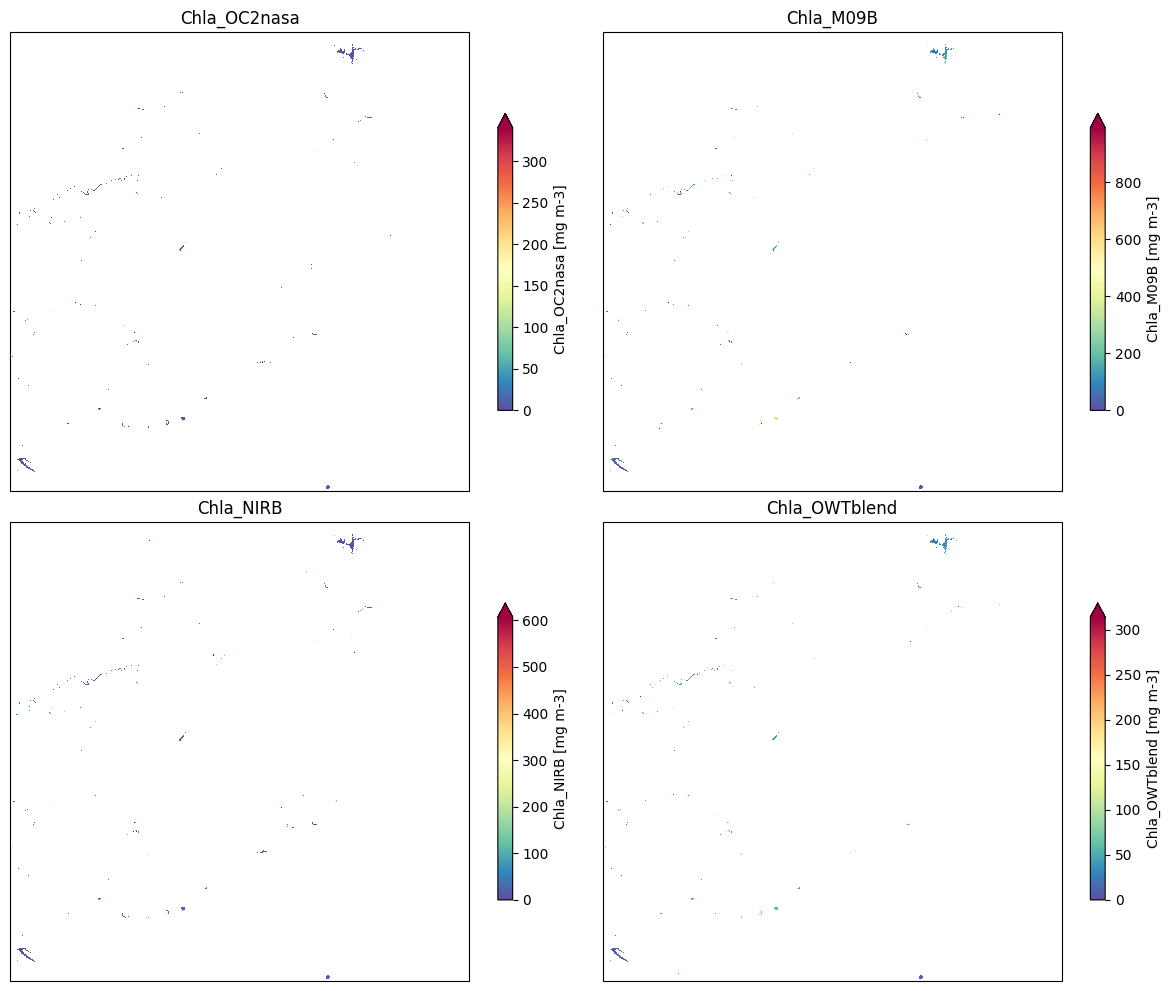

In [4]:
params = ['Chla_OC2nasa', 'Chla_M09B', 'Chla_NIRB', 'Chla_OWTblend']
raster = process.l2b.l2b_prod

str_epsg = str(raster.rio.crs)
zone = str_epsg[-2:]
is_south = str_epsg[2] == '7'
proj = ccrs.UTM(zone, is_south)

fig = plt.figure(figsize=(12, 10))
for ii, param in enumerate(params):
    ax = plt.subplot(2, 2, ii + 1, projection=proj)
    raster[param].plot.imshow(vmin=0., robust=True, cmap=plt.cm.Spectral_r,
                              cbar_kwargs={'shrink': 0.64}, ax=ax)
    ax.set_title(param)
plt.tight_layout()

## Plot Chl outputs with mask

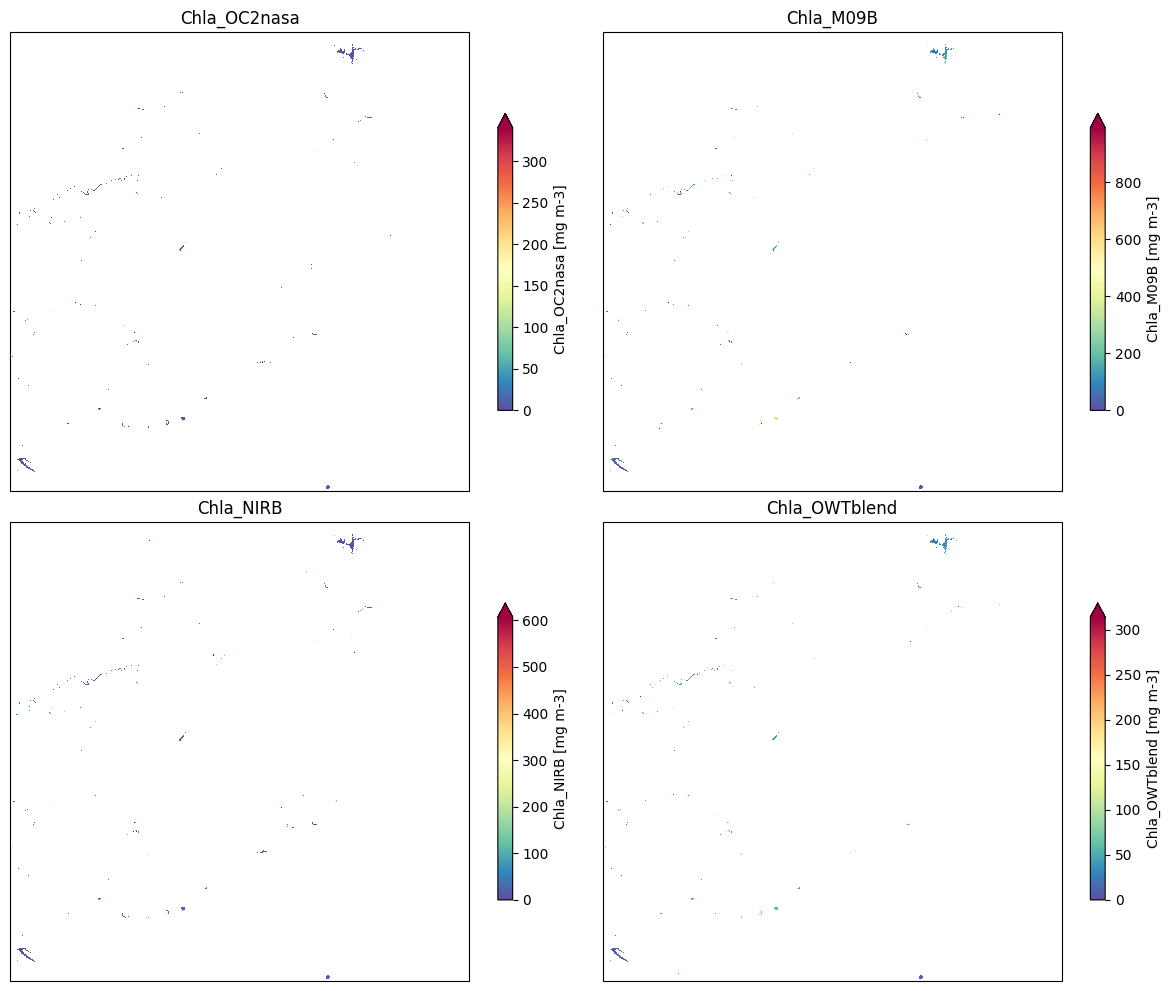

In [5]:
raster_masked = raster.where(raster.mask == 0)
fig = plt.figure(figsize=(12, 10))
for ii, param in enumerate(params):
    ax = plt.subplot(2, 2, ii + 1, projection=proj)
    raster_masked[param].plot.imshow(vmin=0., robust=True, cmap=plt.cm.Spectral_r,
                                     cbar_kwargs={'shrink': 0.64}, ax=ax)
    ax.set_title(param)
plt.tight_layout()

## Zoom on Saint-Ferreol (4-panel)

Matched pixel lon/lat: lon=2.025195, lat=43.436674
Requested lon/lat:     lon=2.025139, lat=43.436611


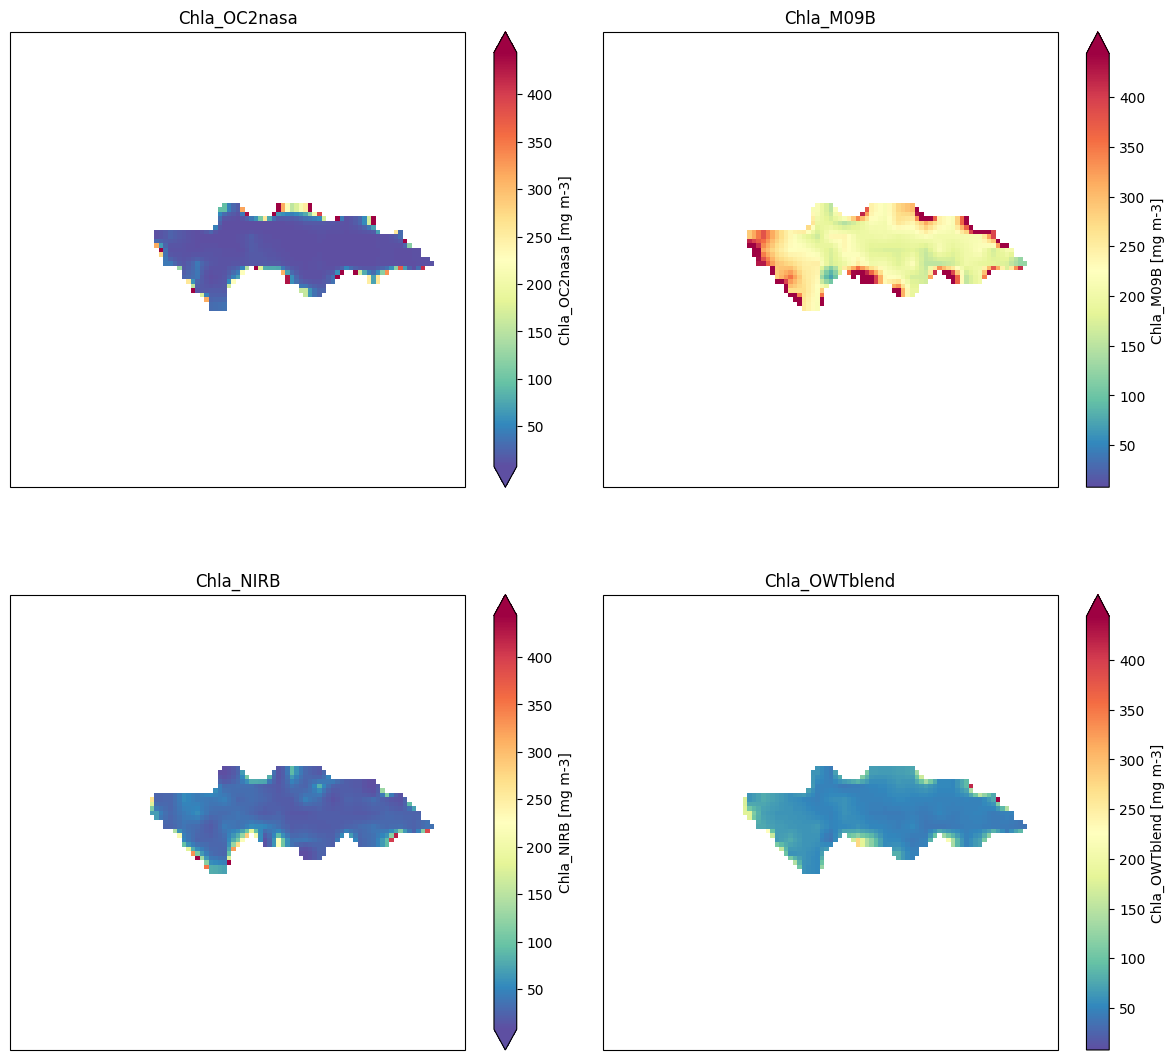

In [6]:
lat_deg = 43 + 26 / 60 + 11.8 / 3600
lon_deg = 2 + 1 / 60 + 30.5 / 3600
x_pt, y_pt = proj.transform_point(lon_deg, lat_deg, src_crs=ccrs.PlateCarree())
x_vals = raster_masked['x'].values
y_vals = raster_masked['y'].values
ix = int(np.argmin(np.abs(x_vals - x_pt)))
iy = int(np.argmin(np.abs(y_vals - y_pt)))
x_match = float(x_vals[ix])
y_match = float(y_vals[iy])

target_lonlat = ccrs.PlateCarree().transform_point(x_match, y_match, src_crs=proj)
print(f'Matched pixel lon/lat: lon={target_lonlat[0]:.6f}, lat={target_lonlat[1]:.6f}')
print(f'Requested lon/lat:     lon={lon_deg:.6f}, lat={lat_deg:.6f}')

zoom_m = 1000

# Build all zoom arrays first so we can use a shared color scale
zoom_data = {}
all_vals = []
for name in params:
    da_zoom = (
        raster_masked[name]
        .where(np.abs(raster_masked['x'] - x_match) <= zoom_m, drop=True)
        .where(np.abs(raster_masked['y'] - y_match) <= zoom_m, drop=True)
    )
    zoom_data[name] = da_zoom
    vals = np.asarray(da_zoom.values).ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size > 0:
        all_vals.append(vals)

if len(all_vals) == 0:
    raise ValueError('No finite values found in zoom window for color scaling.')

all_vals = np.concatenate(all_vals)
vmin = float(np.nanpercentile(all_vals, 2))
vmax = float(np.nanpercentile(all_vals, 98))
if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
    vmin = float(np.nanmin(all_vals))
    vmax = float(np.nanmax(all_vals))

fig, axes = plt.subplots(2, 2, figsize=(12, 12), subplot_kw={'projection': proj})
axes = axes.ravel()
for ax, name in zip(axes, params):
    zoom_data[name].plot.imshow(
        vmin=vmin, vmax=vmax, cmap=plt.cm.Spectral_r,
        cbar_kwargs={'shrink': 0.75, 'label': f'{name} [mg m-3]'},
        ax=ax, transform=proj, interpolation='nearest'
    )
    ax.set_title(name)

plt.tight_layout()

## Zoom on Saint-Ferreol (OWT/SPM/TURB/Kd)

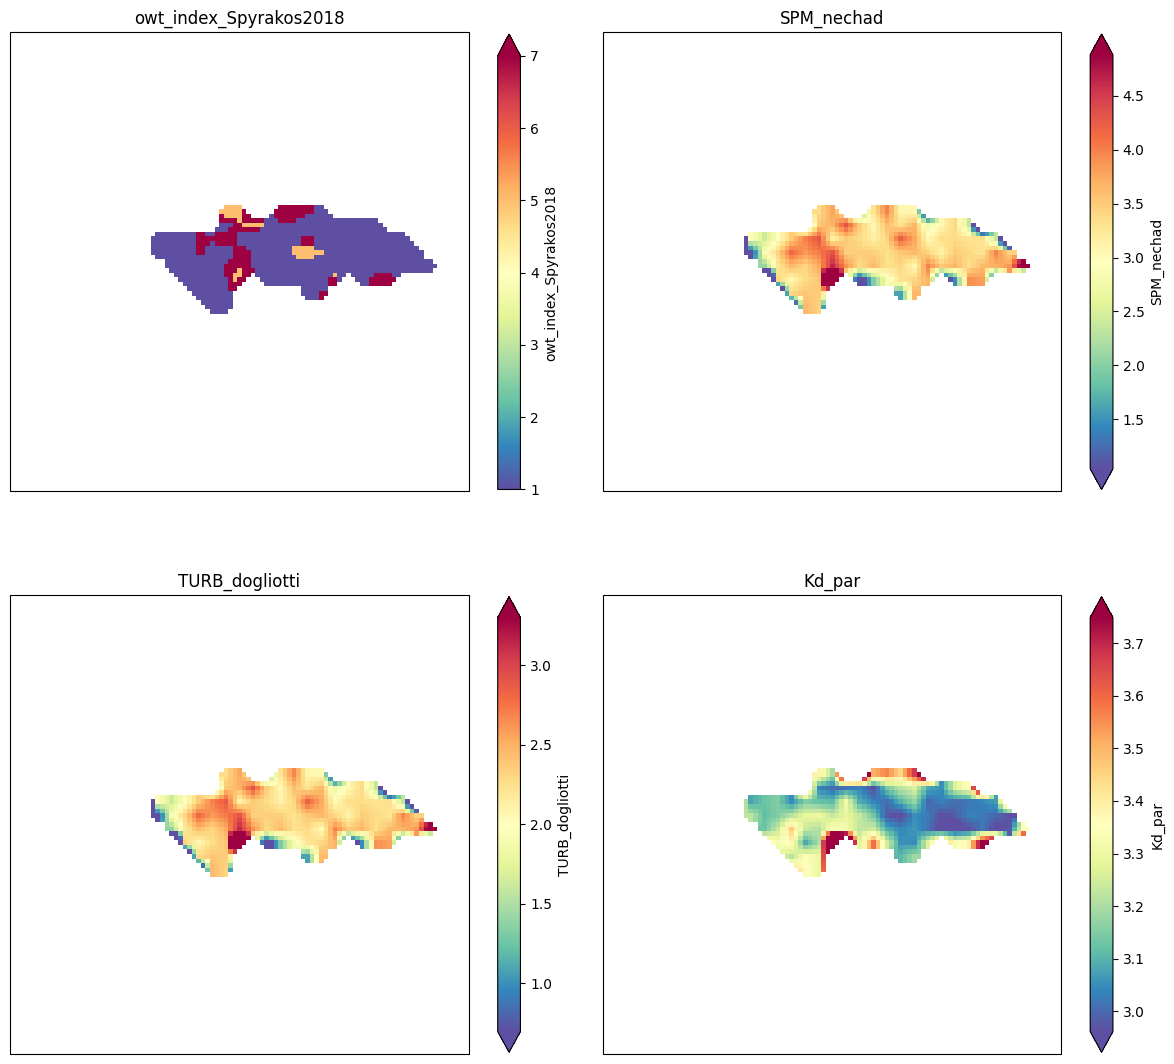

In [8]:
other_params = ['owt_index_Spyrakos2018', 'SPM_nechad', 'TURB_dogliotti', 'Kd_par']

fig, axes = plt.subplots(2, 2, figsize=(12, 12), subplot_kw={'projection': proj})
axes = axes.ravel()

for ax, name in zip(axes, other_params):
    da_zoom = (
        raster_masked[name]
        .where(np.abs(raster_masked['x'] - x_match) <= zoom_m, drop=True)
        .where(np.abs(raster_masked['y'] - y_match) <= zoom_m, drop=True)
    )

    # Each panel uses its own robust scale
    da_zoom.plot.imshow(
        robust=True, cmap=plt.cm.Spectral_r,
        cbar_kwargs={'shrink': 0.75, 'label': name},
        ax=ax, transform=proj, interpolation='nearest'
    )
    ax.set_title(name)

plt.tight_layout()

## Rrs spectra for Saint-Ferreol top-5 OWT classes (mean +/- 1 SD)

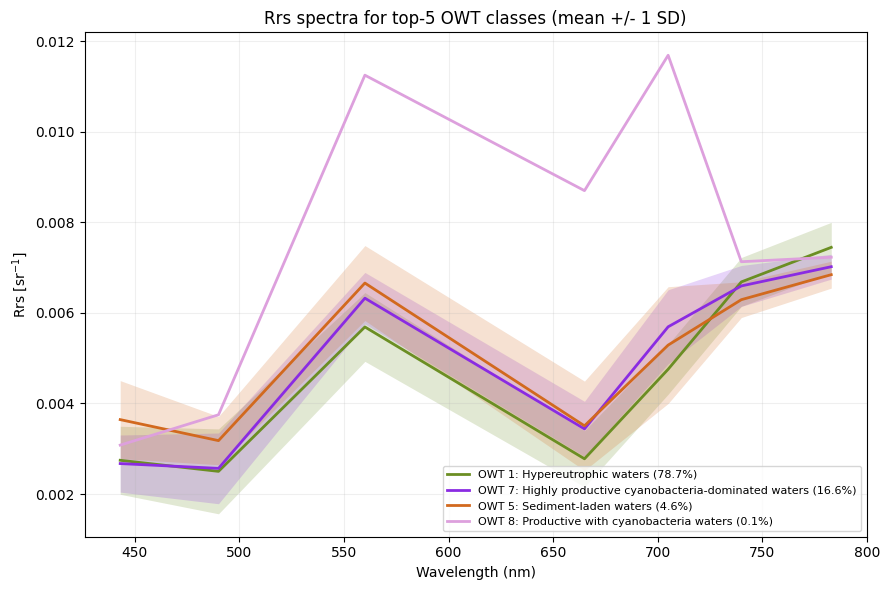

In [9]:
# Rrs spectra grouped by top-5 OWT classes (mean +/- 1 SD), wl <= 800 nm
rrs = prod.raster['Rrs'].where(prod.raster['Rrs']['wl'] <= 800, drop=True)
owt = raster_masked['owt_index_Spyrakos2018']

# Restrict analysis to Saint-Ferreol area (same local window used above)
lake_window = (
    (np.abs(owt['x'] - x_match) <= zoom_m)
    & (np.abs(owt['y'] - y_match) <= zoom_m)
    )
owt_lake = owt.where(lake_window, drop=True)

# OWT metadata and colors (Spyrakos2018)
OWT_spr = GRSl2bgen.OWT(prod.raster, owt_database='Spyrakos2018')

n_sample = 10000
rng = np.random.default_rng(7)

owt_np = np.asarray(owt_lake.values)
h, w = owt_np.shape
valid = np.isfinite(owt_np)
flat = owt_np[valid].astype(int).ravel()

if flat.size == 0:
    raise ValueError('No valid OWT pixels in Saint-Ferreol window.')

uniq, counts = np.unique(flat, return_counts=True)
counts_map = dict(zip(uniq.tolist(), counts.tolist()))
top = sorted(counts_map, key=counts_map.get, reverse=True)[:5]

wl = rrs.coords['wl'].values

fig, ax = plt.subplots(figsize=(9, 6))

for cls in top:
    cls_idx = np.flatnonzero(owt_np == cls)
    if cls_idx.size == 0:
        continue
    if cls_idx.size > n_sample:
        cls_idx = rng.choice(cls_idx, size=n_sample, replace=False)

    y_idx = cls_idx // w
    x_idx = cls_idx % w

    y_coords = owt_lake['y'].values[y_idx]
    x_coords = owt_lake['x'].values[x_idx]

    rrs_cls = rrs.sel(
        y=xr.DataArray(y_coords, dims='pixel'),
        x=xr.DataArray(x_coords, dims='pixel'),
        method='nearest'
    )

    mean = rrs_cls.mean('pixel', skipna=True).values
    std = rrs_cls.std('pixel', skipna=True).values

    desc = OWT_spr.owt_info[cls]['label'].split(': ', 1)[1]
    color = OWT_spr.cmap_owt.colors[cls - 1]
    pct = counts_map[cls] / flat.size * 100

    ax.plot(wl, mean, color=color, lw=2, label=f'OWT {cls}: {desc} ({pct:.1f}%)')
    ax.fill_between(wl, mean - std, mean + std, color=color, alpha=0.2, linewidth=0)

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Rrs [sr$^{-1}$]')
ax.set_title('Rrs spectra for top-5 OWT classes (mean +/- 1 SD)')
ax.legend(ncol=1, fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()

Used 6 files from: /home/somukh/dev_code/fr_2030_SaintFerreol_test
 - S2C_L2B_GRS_20260708T104621_N0512_T31TDJ_20260713T144401_v02_01_09.nc
 - S2C_L2B_GRS_20260715T103621_N0512_T31TDJ_20260722T072138_v02_01_09.nc
 - S2C_L2B_GRS_20260718T104621_N0512_T31TDJ_20260722T082108_v02_01_09.nc
 - S2A_L2B_GRS_20260720T105051_N0512_T31TDJ_20260727T194122_v02_01_09.nc
 - S2C_L2B_GRS_20260728T104621_N0512_T31TDJ_20260803T222614_v02_01_09.nc
 - S2B_L2B_GRS_20260802T104619_N0512_T31TDJ_20260803T184147_v02_01_09.nc


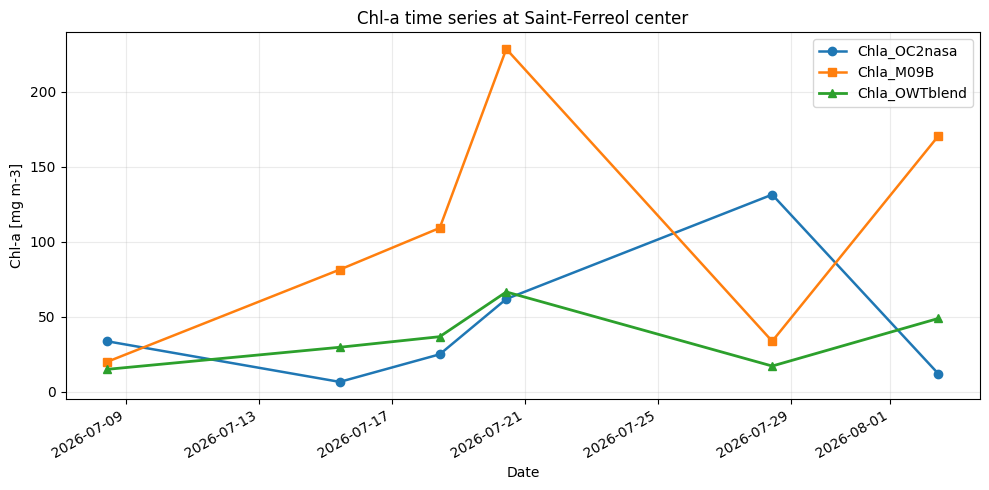

In [3]:
# Time series at Saint-Ferreol center from all output .nc files
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

out_dir_ts = '/home/somukh/dev_code/fr_2030_SaintFerreol_test'
nc_files = sorted(glob.glob(os.path.join(out_dir_ts, '*.nc')))

if len(nc_files) == 0:
    raise FileNotFoundError(f'No .nc files found in {out_dir_ts}')

# Approximate center point of Saint-Ferreol lake (lon/lat, WGS84)
lat_center = 43 + 26 / 60 + 11.8 / 3600
lon_center = 2 + 1 / 60 + 30.5 / 3600

# Tile is T31TDJ for these products -> UTM zone 31N
proj_lake = ccrs.UTM(31, southern_hemisphere=False)
x_center, y_center = proj_lake.transform_point(lon_center, lat_center, src_crs=ccrs.PlateCarree())

dates = []
chl_oc2 = []
chl_m09 = []
chl_blend = []
used_files = []

for fp in nc_files:
    ds = xr.open_dataset(fp)
    try:
        px = ds.sel(x=x_center, y=y_center, method='nearest')

        if 'time' in px.coords:
            t = np.datetime64(px['time'].values)
        else:
            t = np.datetime64('NaT')

        dates.append(t)
        chl_oc2.append(float(px['Chla_OC2nasa'].values))
        chl_m09.append(float(px['Chla_M09B'].values))
        chl_blend.append(float(px['Chla_OWTblend'].values))
        used_files.append(os.path.basename(fp))
    finally:
        ds.close()

dates = np.asarray(dates)
chl_oc2 = np.asarray(chl_oc2, dtype=float)
chl_m09 = np.asarray(chl_m09, dtype=float)
chl_blend = np.asarray(chl_blend, dtype=float)

order = np.argsort(dates)
dates = dates[order]
chl_oc2 = chl_oc2[order]
chl_m09 = chl_m09[order]
chl_blend = chl_blend[order]
used_files = [used_files[i] for i in order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dates, chl_oc2, marker='o', lw=1.8, label='Chla_OC2nasa')
ax.plot(dates, chl_m09, marker='s', lw=1.8, label='Chla_M09B')
ax.plot(dates, chl_blend, marker='^', lw=2.0, label='Chla_OWTblend')

ax.set_xlabel('Date')
ax.set_ylabel('Chl-a [mg m-3]')
ax.set_title('Chl-a time series at Saint-Ferreol center')
ax.grid(True, alpha=0.25)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()

print(f'Used {len(used_files)} files from: {out_dir_ts}')
for f in used_files:
    print(' -', f)